<a href="https://colab.research.google.com/github/manideep52563-art/CodeAlpha_MachineLearning_Tasks/blob/main/Handwritten_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Emotion_Recognition/fer2013.csv
/content/drive/MyDrive/Handwritten_Recognition/emnist-letters-test-selected-columns.csv
/content/drive/MyDrive/Handwritten_Recognition/emnist-letters-train.csv
/content/drive/MyDrive/Disease_prediction_Project /heart.csv


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Handwritten_Recognition"))

['emnist-letters-test-selected-columns.csv', 'emnist-letters-train.csv', 'M.jpg', 'handwritten_character_model_extended.keras', 'handwritten_alphabet_model.keras', 'handwritten_character_model.keras']


In [ ]:
X = X.astype("float32") / 255.0

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load training dataset
data = pd.read_csv("/content/drive/MyDrive/Handwritten_Recognition/emnist-letters-train.csv")

# Split labels and pixels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# Normalize
X = X / 255.0

# Reshape to 28x28x1
X = X.reshape(-1, 28, 28, 1)

# Split into train and test
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", x_train.shape)
print("Test :", x_test.shape)

Train: (71039, 28, 28, 1)
Test : (17760, 28, 28, 1)


In [ ]:
from sklearn.model_selection import train_test_split

# First column = label
y = train.iloc[:, 0].values

# Remaining 784 columns = image pixels
X = train.iloc[:, 1:].values

In [ ]:
X = X.reshape(-1, 28, 28, 1)

print(X.shape)

(88799, 28, 28, 1)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", x_train.shape)
print("Testing :", x_test.shape)

Training: (71039, 28, 28, 1)
Testing : (17760, 28, 28, 1)


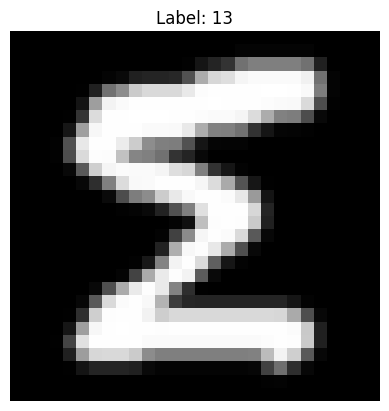

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0].reshape(28,28), cmap="gray")
plt.title("Label: " + str(y_train[0]))
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

# Input Layer
model.add(Input(shape=(28,28,1)))

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (26 alphabets)
model.add(Dense(26, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y_train_corrected = y_train - 1
y_test_corrected = y_test - 1

history = model.fit(
    x_train,
    y_train_corrected,
    validation_data=(x_test, y_test_corrected),
    epochs=10,
    batch_size=64
)

Epoch 1/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.7748 - loss: 0.7318 - val_accuracy: 0.8950 - val_loss: 0.3274
Epoch 2/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.8827 - loss: 0.3644 - val_accuracy: 0.9140 - val_loss: 0.2599
Epoch 3/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.9017 - loss: 0.3001 - val_accuracy: 0.9223 - val_loss: 0.2363
Epoch 4/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.9128 - loss: 0.2594 - val_accuracy: 0.9275 - val_loss: 0.2236
Epoch 5/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.9221 - loss: 0.2319 - val_accuracy: 0.9306 - val_loss: 0.2133
Epoch 6/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9274 - loss: 0.2103 - val_accuracy: 0.9296 - val_loss: 0.2156
Epoch 7/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.9324 - loss: 0.1936 - val_accuracy: 0.9351 - val_loss: 0.2046
Epoch 8/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9366 -

### Retrain with More Epochs

Let's try training the model for a higher number of epochs to allow it more time to learn the patterns in the data. We'll increase the `epochs` from 10 to 20.

In [ ]:
history_extended = model.fit(
    x_train,
    y_train_corrected,
    validation_data=(x_test, y_test_corrected),
    epochs=20, # Increased epochs
    batch_size=64
)

Epoch 1/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.9456 - loss: 0.1456 - val_accuracy: 0.9349 - val_loss: 0.2162
Epoch 2/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.9483 - loss: 0.1372 - val_accuracy: 0.9374 - val_loss: 0.2118
Epoch 3/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.9516 - loss: 0.1286 - val_accuracy: 0.9352 - val_loss: 0.2266
Epoch 4/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9520 - loss: 0.1259 - val_accuracy: 0.9359 - val_loss: 0.2192
Epoch 5/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.9546 - loss: 0.1177 - val_accuracy: 0.9337 - val_loss: 0.2362
Epoch 6/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.9551 - loss: 0.1151 - val_accuracy: 0.9361 - val_loss: 0.2331
Epoch 7/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.9579 - loss: 0.1070 - val_accuracy: 0.9373 - val_loss: 0.2369
Epoch 8/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9585 -

### Evaluate Model After Extended Training

Now, let's evaluate the model's performance on the test set after training for more epochs.

In [ ]:
loss_extended, accuracy_extended = model.evaluate(x_test, y_test_corrected)

print("Test Accuracy after extended training:", accuracy_extended)

555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9346 - loss: 0.3108
Test Accuracy after extended training: 0.9345721006393433


### Save the Updated Model

It's good practice to save the model after training, especially if performance has improved.

In [ ]:
model.save("/content/drive/MyDrive/Handwritten_Recognition/handwritten_character_model_extended.keras")

print("Extended Model Saved Successfully!")

Extended Model Saved Successfully!


In [ ]:
model.save("/content/drive/MyDrive/Handwritten_Recognition/handwritten_alphabet_model.keras")

In [ ]:
print("Minimum Label:", y_train.min())
print("Maximum Label:", y_train.max())
print("Unique Labels:", sorted(set(y_train))[:10], "...", sorted(set(y_train))[-5:])

Minimum Label: 1
Maximum Label: 26
Unique Labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] ... [np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]


In [ ]:
y_train = y_train - 1
y_test = y_test - 1

In [ ]:
y_train_corrected = y_train - 1
y_test_corrected = y_test - 1

In [ ]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=64
)

Epoch 1/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.9697 - loss: 0.0731 - val_accuracy: 0.9365 - val_loss: 0.2957
Epoch 2/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9697 - loss: 0.0751 - val_accuracy: 0.9348 - val_loss: 0.2963
Epoch 3/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9699 - loss: 0.0728 - val_accuracy: 0.9364 - val_loss: 0.3047
Epoch 4/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.9703 - loss: 0.0715 - val_accuracy: 0.9345 - val_loss: 0.3202
Epoch 5/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9716 - loss: 0.0698 - val_accuracy: 0.9364 - val_loss: 0.3067
Epoch 6/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.9712 - loss: 0.0683 - val_accuracy: 0.9376 - val_loss: 0.3112
Epoch 7/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.9725 - loss: 0.0679 - val_accuracy: 0.9355 - val_loss: 0.3328
Epoch 8/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9734 -

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

555/555 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9336 - loss: 0.3377
Test Accuracy: 0.9336148500442505


In [ ]:
model.save("/content/drive/MyDrive/Handwritten_Recognition/handwritten_character_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


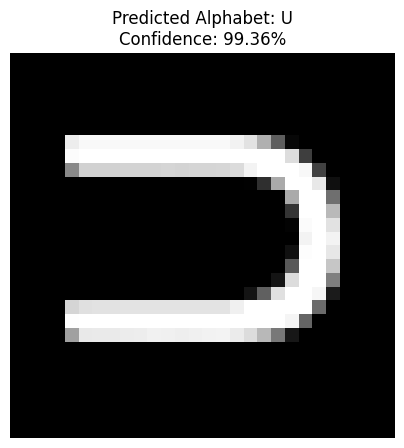

Model Predicted Label: 20
Predicted Alphabet: U
Confidence: 99.36%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# IMAGE PATH
# =========================
image_path = "/content/drive/MyDrive/Handwritten_Recognition/M.jpg"

# =========================
# LOAD IMAGE
# =========================
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# =========================
# INVERT IMAGE
# EMNIST: black background + white letter
# Your image: white background + black letter
# =========================
img = 255 - img

# =========================
# THRESHOLD
# =========================
_, thresh = cv2.threshold(
    img, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# =========================
# FIND LETTER
# =========================
coords = cv2.findNonZero(thresh)

if coords is None:
    raise ValueError("No letter detected in the image.")

x, y, w, h = cv2.boundingRect(coords)

letter = thresh[y:y+h, x:x+w]

# =========================
# KEEP ASPECT RATIO
# RESIZE INTO 20x20
# =========================
scale = min(20 / w, 20 / h)

new_w = max(1, int(w * scale))
new_h = max(1, int(h * scale))

letter = cv2.resize(
    letter,
    (new_w, new_h),
    interpolation=cv2.INTER_AREA
)

# =========================
# CREATE 28x28 IMAGE
# =========================
input_image = np.zeros((28, 28), dtype=np.uint8)

x_offset = (28 - new_w) // 2
y_offset = (28 - new_h) // 2

input_image[
    y_offset:y_offset+new_h,
    x_offset:x_offset+new_w
] = letter

# =========================
# EMNIST ORIENTATION
# =========================
input_image = input_image.T

# =========================
# NORMALIZE
# =========================
input_image = input_image.astype("float32") / 255.0

# =========================
# MODEL INPUT
# =========================
input_image_model = input_image.reshape(1, 28, 28, 1)

# =========================
# PREDICTION
# =========================
prediction = model.predict(input_image_model, verbose=0)

predicted_label = np.argmax(prediction[0])

letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

predicted_letter = letters[predicted_label]

confidence = float(np.max(prediction[0])) * 100

# =========================
# DISPLAY
# =========================
plt.figure(figsize=(5, 5))

plt.imshow(input_image, cmap="gray")
plt.title(
    f"Predicted Alphabet: {predicted_letter}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print("Model Predicted Label:", predicted_label)
print("Predicted Alphabet:", predicted_letter)
print("Confidence:", f"{confidence:.2f}%")